C:\Users\Quang Nguyen\AppData\Local\Temp\ipykernel_30680\4101543440.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  traffic_data[col].fillna(0, inplace=True)



Training MLP model with weather for morning window ...
morning Overall Accuracy: 0.9397

Classification Report:
                accuracy  precision  recall  f1-score   support
low traffic       0.9729     0.9798  0.9729    0.9763  523522.0
medium traffic    0.8955     0.8821  0.8955    0.8888  192292.0
high traffic      0.7926     0.7590  0.7926    0.7754   43339.0
congested         0.7465     0.8193  0.7465    0.7812   12777.0


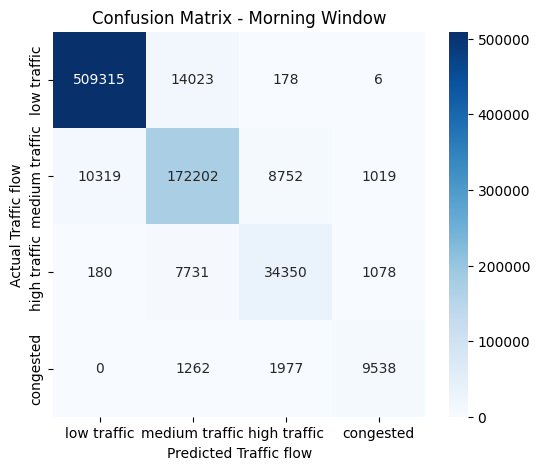


Training MLP model with weather for noon window ...
noon Overall Accuracy: 0.9622

Classification Report:
                accuracy  precision  recall  f1-score   support
low traffic       0.9815     0.9887  0.9815    0.9851  491053.0
medium traffic    0.9522     0.9300  0.9522    0.9409  229787.0
high traffic      0.7987     0.8499  0.7987    0.8235   42353.0
congested         0.9314     0.8692  0.9314    0.8992    8737.0


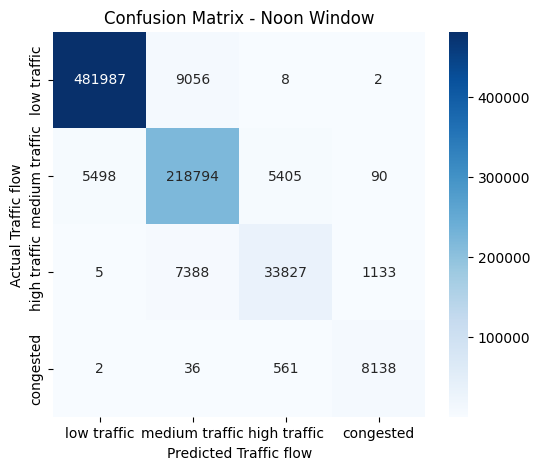


Training MLP model with weather for afternoon window ...
afternoon Overall Accuracy: 0.9498

Classification Report:
                accuracy  precision  recall  f1-score   support
low traffic       0.9847     0.9783  0.9847    0.9815  494894.0
medium traffic    0.9206     0.9151  0.9206    0.9178  218227.0
high traffic      0.7542     0.8182  0.7542    0.7849   45525.0
congested         0.7988     0.8617  0.7988    0.8290   13284.0


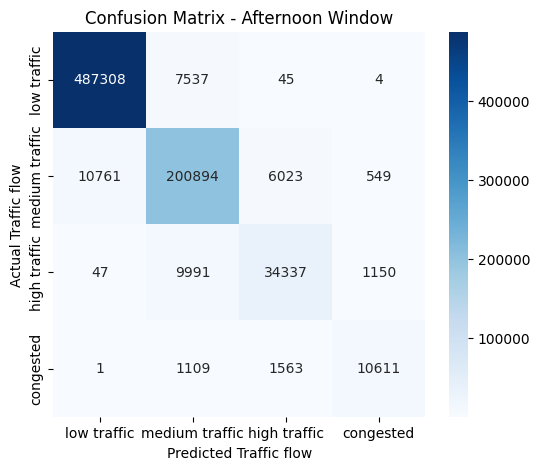


Training MLP model with weather for night window ...
night Overall Accuracy: 0.9615

Classification Report:
                accuracy  precision  recall  f1-score   support
low traffic       0.9804     0.9803  0.9804    0.9804  667575.0
medium traffic    0.8528     0.8509  0.8528    0.8518   95959.0
high traffic      0.7473     0.7278  0.7473    0.7374    7656.0
congested         0.2446     0.7183  0.2446    0.3649     740.0


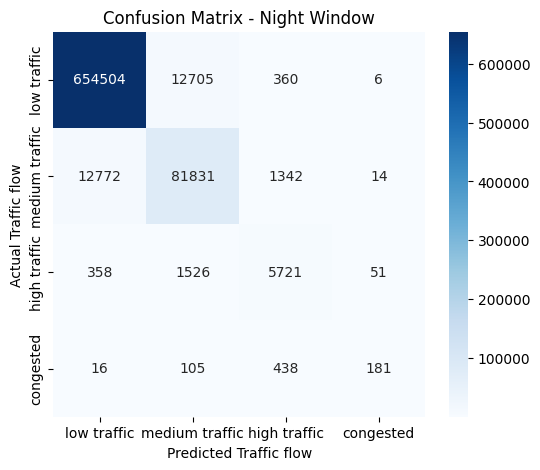

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
traffic_data = pd.read_csv(r"C:\Users\Quang Nguyen\OneDrive\Documents\ENGG2112\trafficData.csv")
traffic_stations = pd.read_csv(r"C:\Users\Quang Nguyen\OneDrive\Documents\ENGG2112\trafficStations.csv")
weather_data = pd.read_csv(r"C:\Users\Quang Nguyen\OneDrive\Documents\ENGG2112\weatherData.csv")

# Prepare date columns
traffic_data['date'] = pd.to_datetime(traffic_data[['year','month','day']])
weather_data['date'] = pd.to_datetime(weather_data['date'])

# Round lat/lon for merging
traffic_stations['lat_rounded'] = traffic_stations['wgs84_latitude'].round(2)
traffic_stations['lon_rounded'] = traffic_stations['wgs84_longitude'].round(2)

# Merge lat/lon and lane_count into traffic_data
traffic_data = traffic_data.merge(
    traffic_stations[['station_key', 'lat_rounded', 'lon_rounded', 'lane_count']],
    on='station_key', how='left'
)

# Merge weather data
unique_locations = traffic_data[['lat_rounded', 'lon_rounded']].drop_duplicates()
unique_dates = traffic_data['date'].drop_duplicates()

weather_filtered = weather_data.merge(unique_locations, on=['lat_rounded', 'lon_rounded'], how='inner')
weather_filtered = weather_filtered[weather_filtered['date'].isin(unique_dates)]

traffic_data = traffic_data.merge(
    weather_filtered,
    on=['lat_rounded', 'lon_rounded', 'date'],
    how='left'
)

# Fill missing weather data
for col in ['daily_rain', 'max_temp', 'min_temp']:
    traffic_data[col].fillna(0, inplace=True)

# Define time windows
time_windows = {
    'morning': [f'hour_{i:02d}' for i in range(6, 10)],
    'noon': [f'hour_{i:02d}' for i in range(10, 16)],
    'afternoon': [f'hour_{i:02d}' for i in range(16, 20)],
    'night': [f'hour_{i:02d}' for i in list(range(20, 24)) + list(range(0, 6))]
}

# Lane-aware classification function
def categorize_traffic_with_lane(count, lane_type):
    if lane_type == 'OneLane':
        if count <= 500:
            return 'low traffic'
        elif count <= 1200:
            return 'medium traffic'
        elif count <= 1800:
            return 'high traffic'
        else:
            return 'congested'
    else:  # Treat all others as TwoOrMoreLanes
        if count <= 1000:
            return 'low traffic'
        elif count <= 2400:
            return 'medium traffic'
        elif count <= 3600:
            return 'high traffic'
        else:
            return 'congested'

# Feature groups
features_base = ['station_key', 'year', 'month', 'day', 'day_of_week', 'public_holiday', 'school_holiday', 'daily_total']
weather_features = ['daily_rain', 'max_temp', 'min_temp']
categorical_features = ['station_key', 'public_holiday', 'school_holiday']
numeric_features = ['year', 'month', 'day', 'day_of_week', 'daily_total'] + weather_features

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

results = {}

for window_name, hours in time_windows.items():
    print(f"\nTraining MLP model with weather for {window_name} window ...")

    # Aggregate features
    traffic_data[f'{window_name}_total'] = traffic_data[hours].sum(axis=1)
    traffic_data[f'{window_name}_max'] = traffic_data[hours].max(axis=1)
    traffic_data[f'{window_name}_mean'] = traffic_data[hours].mean(axis=1)

    # Target with lane-aware classification
    traffic_data['target'] = traffic_data.apply(
        lambda row: categorize_traffic_with_lane(row[f'{window_name}_max'], row['lane_count']),
        axis=1
    )

    # Feature set for the model
    features = features_base + [f'{window_name}_total', f'{window_name}_max', f'{window_name}_mean'] + weather_features

    # Convert categoricals
    traffic_data['public_holiday'] = traffic_data['public_holiday'].astype(int).astype(str)
    traffic_data['school_holiday'] = traffic_data['school_holiday'].astype(int).astype(str)
    traffic_data['station_key'] = traffic_data['station_key'].astype(str)

    X = traffic_data[features]
    y = traffic_data['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # Build and train pipeline
    mlp_clf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
    ])

    mlp_clf.fit(X_train, y_train)
    y_pred = mlp_clf.predict(X_test)

    # Overall accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{window_name} Overall Accuracy: {acc:.4f}")

    # Enhanced classification report
    all_classes = ['low traffic', 'medium traffic', 'high traffic', 'congested']
    present_classes = [cls for cls in all_classes if cls in y_test.unique()]

    report_dict = classification_report(
        y_test, y_pred, labels=present_classes, target_names=present_classes, output_dict=True)

    report_df = pd.DataFrame(report_dict).transpose().loc[present_classes]

    # Confusion matrix and per-class accuracy
    cm = confusion_matrix(y_test, y_pred, labels=present_classes)
    per_class_acc = [(cm[i][i] / cm[i].sum()) if cm[i].sum() > 0 else 0 for i in range(len(present_classes))]
    report_df.insert(0, 'accuracy', per_class_acc)

    print("\nClassification Report:")
    print(report_df[['accuracy', 'precision', 'recall', 'f1-score', 'support']].round(4))

    # Plot confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_classes,
                yticklabels=present_classes)
    plt.xlabel('Predicted Traffic flow')
    plt.ylabel('Actual Traffic flow')
    plt.title(f'Confusion Matrix - {window_name.capitalize()} Window')
    plt.show()

    results[window_name] = {
        'model': mlp_clf,
        'accuracy': acc,
        'y_test': y_test,
        'y_pred': y_pred,
        'report': report_df
    }
